In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("TATA_car_sales_cleaned.csv")


In [4]:
df.shape

(250000, 34)

In [5]:
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style="whitegrid")

In [6]:
df["total_revenue"] = df["units_sold"]*df["average_sale_price"]
print(df["total_revenue"].head())

0    40097406.16
1    41699721.28
2    19911411.60
3    82188438.64
4    47465389.90
Name: total_revenue, dtype: float64


In [7]:
yearly_revenue = df.groupby("year")["total_revenue"].sum()/1e12
print(yearly_revenue)

year
2015    1.400966
2016    1.423573
2017    1.399290
2018    1.407845
2019    1.419192
2020    1.415826
2021    1.413384
2022    1.394713
2023    1.401175
2024    1.401799
Name: total_revenue, dtype: float64


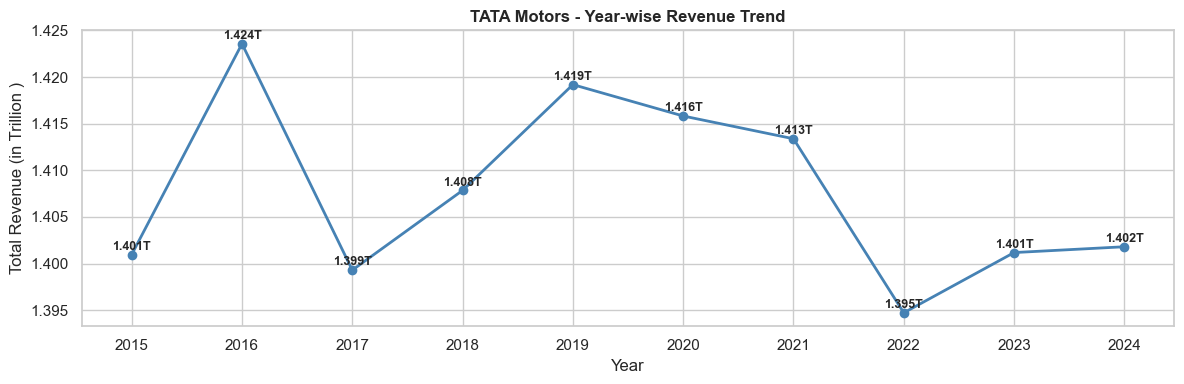

In [8]:
plt.plot(yearly_revenue.index, yearly_revenue.values, marker='o', color='Steelblue', linewidth=2)
plt.title('TATA Motors - Year-wise Revenue Trend',fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Revenue (in Trillion )')
plt.xticks(yearly_revenue.index)
plt.tight_layout()
for x, y in zip(yearly_revenue.index, yearly_revenue.values):
    plt.text(x, y + 0.0005, f'{y:.3f}T', ha='center', fontsize=9,fontweight = 'bold')
plt.show()

In [9]:
car_unitsold = df.groupby("car_model")["units_sold"].sum().sort_values(ascending=False).head(5)
print(car_unitsold)

car_model
Tatamodel_9     7877324
Tatamodel_16    7782467
Tatamodel_5     7713501
Tatamodel_29    7694655
Tatamodel_47    7684313
Name: units_sold, dtype: int64


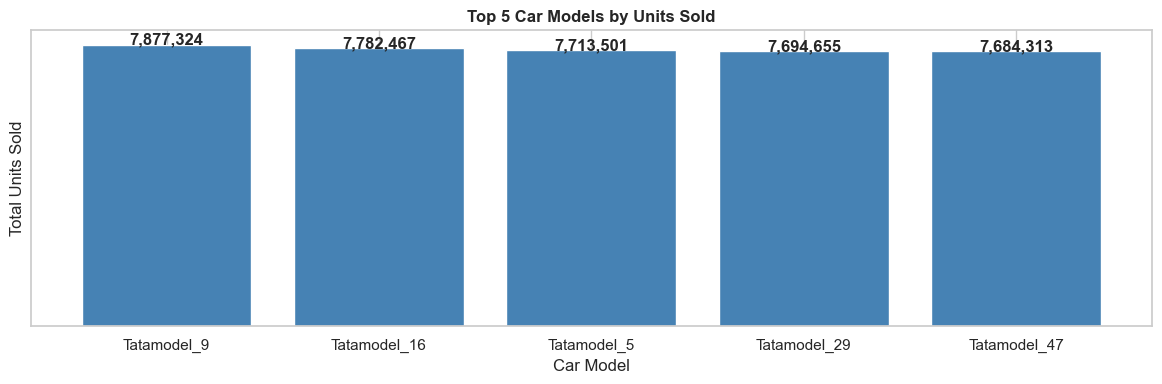

In [10]:
plt.bar( car_unitsold.index,car_unitsold.values, color='steelblue')
plt.title('Top 5 Car Models by Units Sold', fontweight='bold')
plt.xlabel('Car Model')
plt.ylabel('Total Units Sold')

for x, y in zip(car_unitsold.index, car_unitsold.values):
    plt.text(x, y + 1000, f'{y:,.0f}', ha='center', fontsize=12,fontweight = 'bold')

plt.tight_layout()
plt.yticks([])
plt.show()

In [11]:
region_revenue = df.groupby("region")["total_revenue"].sum()/1e12
print(region_revenue)

region
Central      2.352181
East         2.353612
North        2.336764
Northeast    2.355007
South        2.355963
West         2.324237
Name: total_revenue, dtype: float64


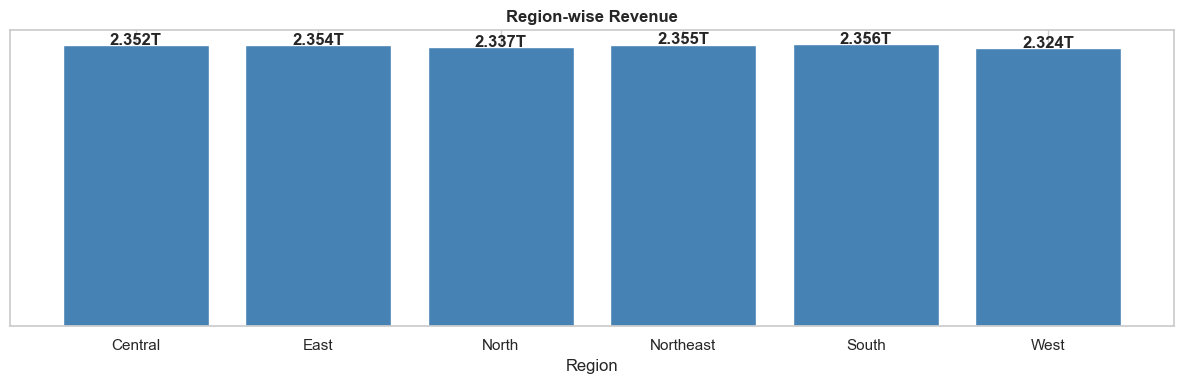

In [12]:
plt.figure(figsize=(12, 4))
plt.bar(region_revenue.index, region_revenue.values, color='steelblue')
plt.title('Region-wise Revenue', fontweight='bold')
plt.xlabel('Region')
plt.yticks([])

for x, y in zip(region_revenue.index, region_revenue.values):
    plt.text(x, y + 0.001, f'{y:.3f}T', ha='center', fontsize=12 , fontweight ='bold')

plt.tight_layout()
plt.show()

In [13]:
test_drive = df.groupby('test_drive')['units_sold'].sum()
print(test_drive)

test_drive
False    187764348
True     187749858
Name: units_sold, dtype: int64


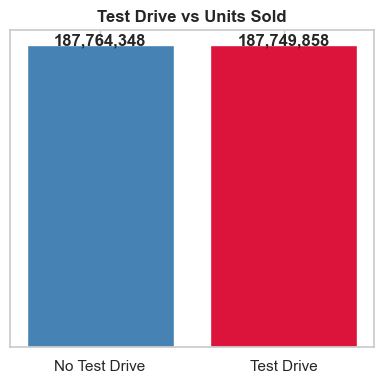

In [34]:
plt.figure(figsize=(4, 4))
plt.bar(['No Test Drive', 'Test Drive'], test_drive.values, color=['steelblue', 'crimson'])
plt.title('Test Drive vs Units Sold', fontweight='bold')
plt.yticks([])

for x, y in zip(['No Test Drive', 'Test Drive'], test_drive.values):
    plt.text(x, y + 50000, f'{y:,.0f}', ha='center', fontsize=12,fontweight = 'bold')

plt.tight_layout()
plt.show()

In [15]:
age_income = df.groupby(["customer_age","customer_income_group"])["units_sold"].sum()
print(age_income.head(10))

customer_age  customer_income_group
18            High                     2189726
              Low                      2142348
              Medium                   2187174
19            High                     2135294
              Low                      2224504
              Medium                   2240403
20            High                     2128073
              Low                      2091896
              Medium                   2213869
21            High                     2215327
Name: units_sold, dtype: int64


In [16]:
bins = [18, 30, 45, 60, 75]
labels = ['18-30', '31-45', '46-60', '60+']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)
print(df['age_group'].value_counts())

age_group
31-45    66164
46-60    65785
60+      60844
18-30    52878
Name: count, dtype: int64


In [17]:
age_income = df.groupby(['age_group', 'customer_income_group'])['units_sold'].sum().unstack()
print(age_income)

customer_income_group      High       Low    Medium
age_group                                          
18-30                  26626580  26501117  26622320
31-45                  32983658  33227065  33105011
46-60                  33197192  32585752  32894572
60+                    30393653  30633673  30224365


C:\Users\rambh\AppData\Local\Temp\ipykernel_11356\3057990422.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income = df.groupby(['age_group', 'customer_income_group'])['units_sold'].sum().unstack()


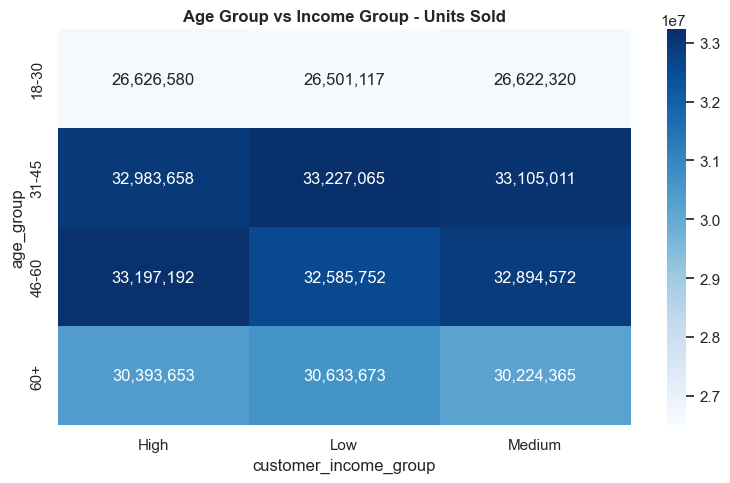

In [18]:
plt.figure(figsize=(8, 5))
sns.heatmap(age_income, annot=True, fmt=',', cmap='Blues')
plt.title('Age Group vs Income Group - Units Sold', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
discount = df.groupby("discount_reason")["dealer_discount_pct"].mean().sort_values(ascending=False)
print(discount)

discount_reason
Festival            9.987673
No Discount         9.987563
New Model Launch    9.985466
Clearance           9.983884
Name: dealer_discount_pct, dtype: float64


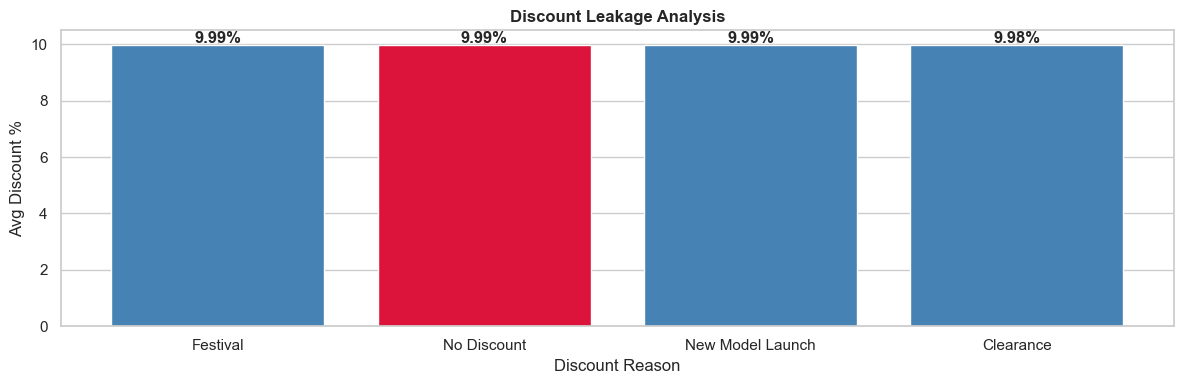

In [38]:
plt.Figure(figsize=(8,4))
color = ['Crimson' if x == 'No Discount' else 'steelblue' for x in discount.index]
plt.bar(discount.index,discount.values, color = color)
plt.title("Discount Leakage Analysis",fontweight = 'bold')
plt.xlabel('Discount Reason')
plt.ylabel('Avg Discount %')

for x, y in zip(discount.index, discount.values):
    plt.text(x, y + 0.05, f'{y:.2f}%', ha='center', fontsize=12,fontweight = 'bold')

plt.tight_layout()



plt.show()

In [46]:
conquest = df[df['previous_car_brand'] != 'Unknown'].groupby('previous_car_brand')['units_sold'].sum().sort_values(ascending=False).head(10)
print(conquest)

previous_car_brand
Not Applicable    188028316
Hyundai            31504407
Tata               31488795
Ford               31257369
Honda              31149006
Maruti             30734822
Name: units_sold, dtype: int64


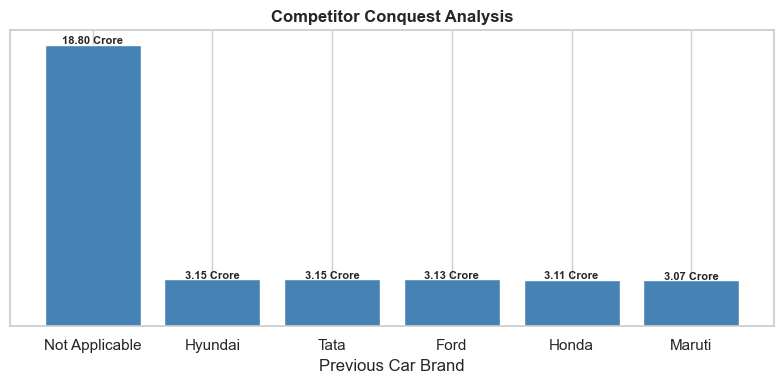

In [47]:
plt.figure(figsize= (8,4))
plt.bar(conquest.index,conquest.values , color = 'steelblue')
plt.title("Competitor Conquest Analysis", fontsize = 12 , fontweight = 'bold')
plt.xlabel('Previous Car Brand')
plt.yticks([])

for x, y in zip(conquest.index, conquest.values):
    plt.text(x, y + 200000, f'{y/1e7:.2f} Crore', ha='center', fontsize=8 , fontweight = 'bold')
plt.tight_layout()    
plt.show()

In [49]:
delivery = df.groupby('delivery_time_days')['customer_rating'].mean().reset_index()
print(delivery.head(20))

    delivery_time_days  customer_rating
0                    1         3.263503
1                    2         3.257946
2                    3         3.242470
3                    4         3.250368
4                    5         3.251588
5                    6         3.254293
6                    7         3.235823
7                    8         3.258553
8                    9         3.235868
9                   10         3.249552
10                  11         3.259663
11                  12         3.230314
12                  13         3.243752
13                  14         3.252645
14                  15         3.240665
15                  16         3.239389
16                  17         3.261137
17                  18         3.240390
18                  19         3.260835
19                  20         3.260667


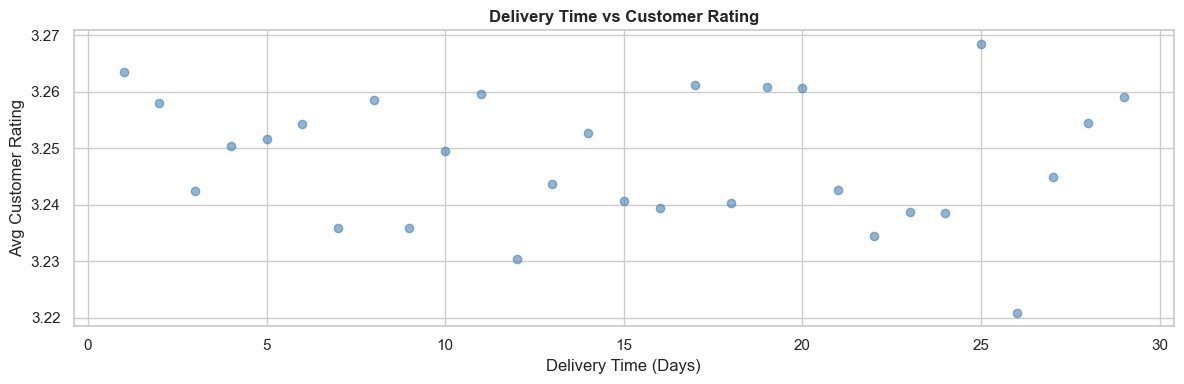

In [53]:
plt.figure(figsize=(12, 4))
plt.scatter(delivery['delivery_time_days'], delivery['customer_rating'], color='steelblue', alpha=0.6)
plt.title('Delivery Time vs Customer Rating', fontweight='bold')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Avg Customer Rating')
plt.tight_layout()
plt.show()